# Activity 1: Earthquake cycle and dislocation models


##  strike-slip 1D dislocation model

### Understanding Interseismic Deformation Due to Strike-Slip Faulting

In this lab we will investigate the strain accumulation that occurs between earthquakes. We will use the half-space model for interseismic deformation for a strike-slip fault. The diagram bellow explains the parameters used in the anlytical model as described by Savage and Buford (1973).
<img src="https://github.com/koulali/ceg3707/blob/main/img/fig25.png?raw=true" alt="Drawing" style="width: 400px;"/>

The analytical solution for the interseismic deformation is:

$$
v = \dfrac{s}{\pi}\arctan\left(\dfrac{x}{D}\right)
$$

where

v : is the fault-parallel surface displacement / surface velocity

s : is the slip rate of the fault

x : is the distance from the fault

D : is the locking depth


### Part 1: Understanding the half-space model for interseismic deformation for a strike-slip fault


### Question 1:

Write a python function returning the model surface displacements using the formula above.

In [1]:
import numpy as np

def forward_ss(x,s,D):
    ''' 
    x and D are numpy arrays
    '''
    v = s/np.pi*np.arctan(x/D)
    return v

### Question 2:
Plot the velocities resulting from a model with a slip rate of s = 1mm/yr, locking depth of 15 km, using 150km in both directions of the fault;

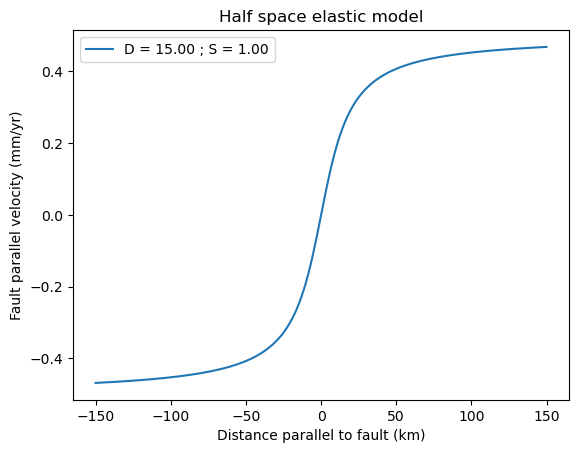

In [2]:
import matplotlib.pyplot as plt
%matplotlib inline

x = np.arange(-150,150,0.1);
s = 1;
D = 15;
vx = forward_ss(x,s,D)
plt.plot(x,vx,label=r"D = %3.2f ; S = %3.2f"%(D,s))
plt.legend(loc=2)
plt.grid(False)
plt.xlabel('Distance parallel to fault (km)')
plt.ylabel('Fault parallel velocity (mm/yr)')
plt.title('Half space elastic model')
plt.savefig('/home/koulali/Downloads/test.png',dpi=360)
plt.show()

### Question 3:
Now let's see how changing various parameters affects the resultant fault-parallel motions. Plot three models (curves) on one graph.

1st - Plot the same parameters as you did in 1B (plot color=red)

2nd - Plot the same, except double the fault slip rate to 2 mm/yr (plot color=blue)

3rd - Repeat again, but make fault slip rate 4 mm/yr (plot color=black)

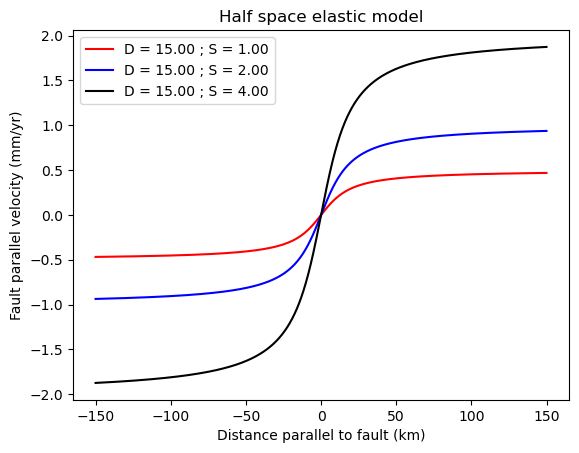

In [3]:
slip_rates = [1, 2, 4]
colours = ['red', 'blue', 'black']
for i,s in enumerate(slip_rates):
    vx = forward_ss(x,s,D)
    plt.plot(x,vx,color=colours[i],label=r"D = %3.2f ; S = %3.2f"%(D,s))
plt.legend(loc=2)
plt.grid(False)
plt.xlabel('Distance parallel to fault (km)')
plt.ylabel('Fault parallel velocity (mm/yr)')
plt.title('Half space elastic model')
plt.show()

### Question 4:
Now let's see the effects of different locking depths on the fault-parallel surface velocities. Make three more plots on one graph within +/- 150 km of the fault.

1st - Plot the fault-parallel motions for slip=1 mm/yr, locking depth=5 km (color = red).

2nd - Change locking depth to 20 km and plot the same range (color = blue).

3rd - Change locking depth to 50 km and plot the same range (color = black).

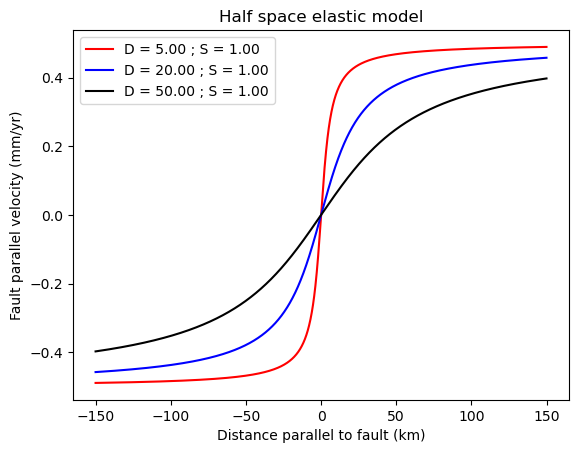

In [4]:
s = 1.;
locking_depths = [5, 20, 50]
colours = ['red', 'blue', 'black']
for i,D in enumerate(locking_depths):
    vx = forward_ss(x,s,D)
    plt.plot(x,vx,color=colours[i],label=r"D = %3.2f ; S = %3.2f"%(D,s))
plt.legend(loc=2)
plt.grid(False)
plt.xlabel('Distance parallel to fault (km)')
plt.ylabel('Fault parallel velocity (mm/yr)')
plt.title('Half space elastic model')
plt.show()

### Question 5:

Lets say that you don't want your fault to be located at 0 km on the x-axis. Modify the analytical interseismic strike-slip fault model so that you can move the fault around horizontally on the plot. This requires you to define a new variable in the strike-slip equation, $\delta$. This $\delta$ variable will control the horizontal location of the fault on the plot.

Make three plots on the same graph from -150 to 150.

1st-plot slip=1 mm/yr, locking depth=15 km, centered at (0, 0) (plot color = red).

2nd-plot the same, but center the fault at x=50 km (plot color=blue).

3rd-plot the same, but center the fault at x=-50 km (plot color=black).

Note that the x-axis should now just be labeled "distance (km)", since the fault is in different locations for each curve plotted.

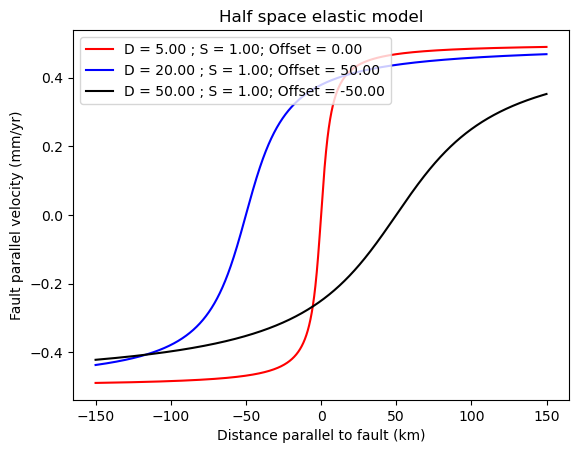

In [5]:
s = 1.;
D = 5.;
offsets = [0., 50., -50.]
colours = ['red', 'blue', 'black']
for i,D in enumerate(locking_depths):
    vx = forward_ss(x+offsets[i],s,D)
    plt.plot(x,vx,color=colours[i],label=r"D = %3.2f ; S = %3.2f; Offset = %3.2f"%(D,s,offsets[i]))
plt.legend(loc=2)
plt.grid(False)
plt.xlabel('Distance parallel to fault (km)')
plt.ylabel('Fault parallel velocity (mm/yr)')
plt.title('Half space elastic model')
plt.show()

### Question 6:

Using what you have learned from your interseismic plots, and the previous questions, where would you put GPS sites relative to a fault to figure out the fault slip rate during the interseismic period? Why? At least how many sites would you need?

## Part 2: Modeling Interseismic GPS Data From The north Anatolian fault


The North Anatolian Fault (NAF) is a major continental right-lateral transform fault, accomodating the motion between Anatolia and the Eurasian plate with the Arabian plate (McKenzie, 1972). GPS and InSAR observations provided important constraints for estimating the present-day slip rate for the NAF (e.g. Reilinger et al., 2006). 

Your objective here is to use the GPS surface velocities to estimate the slip rate and locking depth the NAF, using what you have learned in part1. A velocity profiles across the NAF is provided "NAF_crossGPS.csv". 


<img src="https://github.com/koulali/ceg3707/blob/main/img/fig28.png?raw=true" alt="Drawing" style="width: 650px;"/>
Fig 2: Map of Turkey including the southern Black Sea and showing the traces of the North Anatolian and East Anatolian faults (From Molnar Dayem, 2010).

<img src="https://github.com/koulali/ceg3707/blob/main/img/fig27.png?raw=true" alt="Drawing" style="width: 500px;"/>
Fig 3: Location of GPS velocity profile.

### Question 1:

Plot fault parallel displacement versus fault normal distance.

In [6]:
!wget https://raw.githubusercontent.com/koulali/ceg3707/main/data/NAF_crossGPS.csv

--2023-10-18 15:56:51--  https://raw.githubusercontent.com/koulali/ceg3707/main/data/NAF_crossGPS.csv
Loaded CA certificate '/etc/ssl/certs/ca-certificates.crt'
Resolving raw.githubusercontent.com (raw.githubusercontent.com)... 185.199.109.133, 185.199.111.133, 185.199.110.133, ...
Connecting to raw.githubusercontent.com (raw.githubusercontent.com)|185.199.109.133|:443... connected.
HTTP request sent, awaiting response... 200 OK
Length: 1490 (1.5K) [text/plain]
Saving to: ‘NAF_crossGPS.csv.1’

NAF_crossGPS.csv.1  100%[===================>]   1.46K  --.-KB/s    in 0s      

2023-10-18 15:56:52 (5.48 MB/s) - ‘NAF_crossGPS.csv.1’ saved [1490/1490]



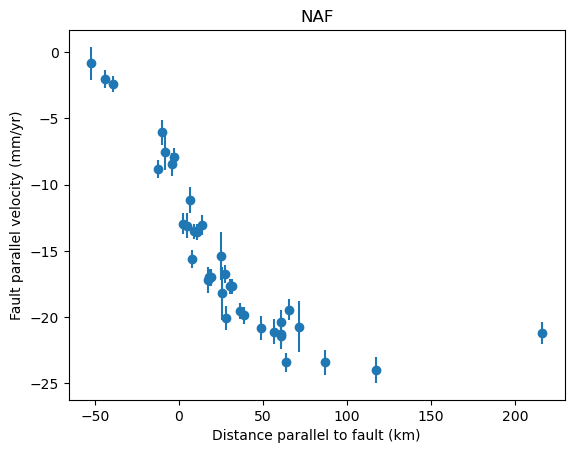

In [10]:
data = np.genfromtxt('NAF_crossGPS.csv',skip_header=2,delimiter=',')
dist = data[:,1]
vel  = data[:,4]
sig  = data[:,5]

plt.errorbar(dist,vel,sig,fmt='o')
plt.grid(False)
plt.xlabel('Distance parallel to fault (km)')
plt.ylabel('Fault parallel velocity (mm/yr)')
plt.title('NAF')
plt.show()

### Question 2:

Use your dislocation model to estimate the slip rate and the locking depth.

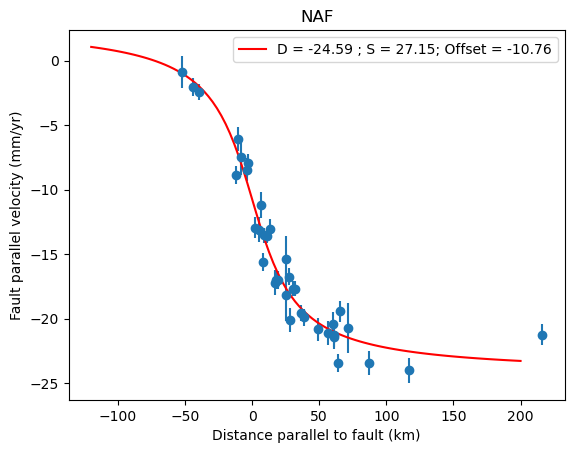

In [12]:
from scipy.optimize import curve_fit

def forward_ss_offset(x,s,D,offvel):
    ''' 
    x and D are numpy arrays
    '''
    v = offvel+s/np.pi*np.arctan(x/D)
    return v


popt, pcov = curve_fit(forward_ss_offset, dist, vel)
xfine = np.linspace(-120., 200., 100)

#
plt.errorbar(dist,vel,sig,fmt='o')
plt.plot(xfine, forward_ss_offset(xfine, popt[0], popt[1],popt[2]),
        'r-',label=r"D = %3.2f ; S = %3.2f; Offset = %3.2f"%(popt[1],popt[0],popt[2]))
plt.legend(loc=1)
plt.grid(False)
plt.xlabel('Distance parallel to fault (km)')
plt.ylabel('Fault parallel velocity (mm/yr)')
plt.title('NAF')
plt.show()

### Question 3:

Plot the model residuals and calculate the RMS. Provide and explain three reasons for why the differences between the model and the data are non-zero.

### Question 4:

Considering that the parallel velocities contain a rotational component of Anatolia with respect to Eurasia, rewrite your model by including a rotational term (cf. lectures) that will take into account this effect.
If we consider that this effect applies only to south of the NAF, re-estimate the fault parameters. How your results compare to question 2 ?

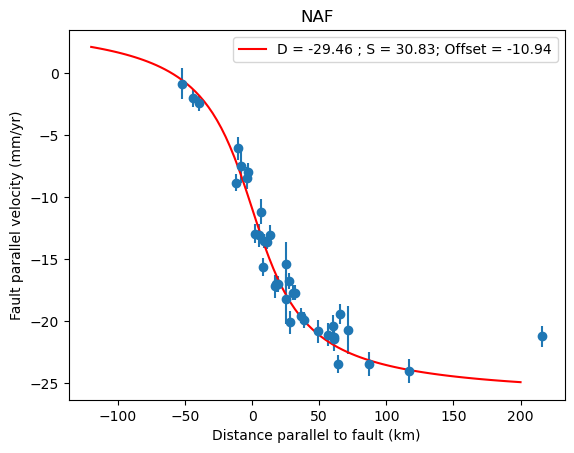

In [13]:
def forward_ss_rot(x,s,D,offvel,theta):
    ''' 
    x and D are numpy arrays
    '''
    v = np.zeros_like(x)
    for i in range(len(x)):
        if (x[i]<=0):
            v[i] = offvel+s/np.pi*np.arctan(x[i]/D)
        elif(x[i]>0):
            v[i] = offvel+s/np.pi*np.arctan(x[i]/D)+x[i]*theta

    return v


popt, pcov = curve_fit(forward_ss_rot, dist, vel)
xfine = np.linspace(-120., 200., 100)

#
plt.errorbar(dist,vel,sig,fmt='o')
plt.plot(xfine, forward_ss_offset(xfine, popt[0], popt[1],popt[2]),
        'r-',label=r"D = %3.2f ; S = %3.2f; Offset = %3.2f"%(popt[1],popt[0],popt[2]))

plt.legend(loc=1)
plt.grid(False)
plt.xlabel('Distance parallel to fault (km)')
plt.ylabel('Fault parallel velocity (mm/yr)')
plt.title('NAF')
plt.show()

### Question 5: (Optional)

If we assume that the last earthquake ruptured on the NAF was in 1999, when do you expect the next ?